<style>
/* Keep the lesson inside the available notebook width. */
.workshop-reading { background:#FFFFFF; color:#1D2939; color-scheme:light;
  padding:16px; border:1px solid #D0D5DD; border-radius:12px;
  line-height:1.6; box-sizing:border-box; max-width:100%; overflow-wrap:anywhere; }
.workshop-reading :is(p,li,td,th,h1,h2,h3,h4,summary,strong,b,small,em) { color:inherit; }
.workshop-reading a { color:#1849A9 !important; text-decoration:underline; }
.workshop-reading :is(code,kbd) { color:#1D2939 !important; background:#F2F4F7 !important;
  border-radius:4px; padding:1px 4px; overflow-wrap:anywhere; }
.workshop-reading table { display:block; max-width:100%; overflow-x:auto;
  color:#1D2939; background:#FFFFFF; }
.workshop-reading :is(th,td) { border-color:#D0D5DD; background:transparent; }
.workshop-reading pre { color:#1D2939; background:#F8FAFC; white-space:pre-wrap;
  max-width:100%; overflow-x:auto; box-sizing:border-box; }
.workshop-reading :is(img,svg) { max-width:100%; height:auto; }
.workshop-reading .workshop-flex { display:flex; flex-wrap:wrap; max-width:100%; }
.workshop-reading .workshop-flex > * { min-width:0; max-width:100%; box-sizing:border-box; }
.workshop-widget { background:#FFFFFF !important; color:#1D2939 !important; color-scheme:light; }
.workshop-widget :is(label,.widget-label) { color:#1D2939 !important; }
.workshop-widget textarea { background:#FFFFFF !important; color:#1D2939 !important;
  caret-color:#1D2939; border:1px solid #667085 !important; }
.workshop-widget button { background:#175CD3 !important; color:#FFFFFF !important; }
.workshop-widget button.mod-success { background:#067647 !important; }
.workshop-widget button.mod-danger { background:#B42318 !important; }
.workshop-widget button:focus-visible, .workshop-reading a:focus-visible {
  outline:3px solid #B54708; outline-offset:3px; }
</style>
<div class="workshop-reading" style="background:#FFFFFF;color:#1D2939;color-scheme:light;max-width:100%;box-sizing:border-box;padding:16px;border:1px solid #D0D5DD;border-radius:12px;overflow-wrap:anywhere">

# Workbook 6 · Read one invoice into Excel

Questions 19–20

<div style='background:#EFF8FF;border:1px solid #B2DDFF;border-left:5px solid #175CD3;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#EFF8FF;border:1px solid #B2DDFF;color:#175CD3;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>START HERE</span><div style='margin-top:9px'>Select the <b>.venv</b> Python kernel. Run the setup cell below with <b>Shift + Enter</b> or its <b>▶ play button</b>, then run each activity cell in order. The setup code can stay collapsed. If a button does not respond after reopening or restarting, rerun setup and that question's cell.</div></div>

Submit & save writes to **_for_STUDENT/tasks/06_receipt_ocr/answers.json**.

These files stay in your own Codespace unless you choose to share them. Use your own accounts and API keys for external AI services.

</div>

In [1]:
from pathlib import Path
import sys
import random

# Works when the kernel starts at the repository root or in _for_STUDENT/notebooks/.
WORKSHOP_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "_for_TRAINER" / "llm_workshop" / "worksheet.py").is_file()
)
if str(WORKSHOP_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSHOP_ROOT))
sys.path.insert(0, str(WORKSHOP_ROOT / "_for_TRAINER"))

from IPython.display import HTML, display
from llm_workshop.prompt_card import copyable_prompt
from llm_workshop.quiz import readme_quiz
from llm_workshop.worksheet import worksheet_box
from llm_workshop.course import answer_path
from llm_workshop.receipt_support import show_receipt_preview, preview_spreadsheet

<style>
/* Keep the lesson inside the available notebook width. */
.workshop-reading { background:#FFFFFF; color:#1D2939; color-scheme:light;
  padding:16px; border:1px solid #D0D5DD; border-radius:12px;
  line-height:1.6; box-sizing:border-box; max-width:100%; overflow-wrap:anywhere; }
.workshop-reading :is(p,li,td,th,h1,h2,h3,h4,summary,strong,b,small,em) { color:inherit; }
.workshop-reading a { color:#1849A9 !important; text-decoration:underline; }
.workshop-reading :is(code,kbd) { color:#1D2939 !important; background:#F2F4F7 !important;
  border-radius:4px; padding:1px 4px; overflow-wrap:anywhere; }
.workshop-reading table { display:block; max-width:100%; overflow-x:auto;
  color:#1D2939; background:#FFFFFF; }
.workshop-reading :is(th,td) { border-color:#D0D5DD; background:transparent; }
.workshop-reading pre { color:#1D2939; background:#F8FAFC; white-space:pre-wrap;
  max-width:100%; overflow-x:auto; box-sizing:border-box; }
.workshop-reading :is(img,svg) { max-width:100%; height:auto; }
.workshop-reading .workshop-flex { display:flex; flex-wrap:wrap; max-width:100%; }
.workshop-reading .workshop-flex > * { min-width:0; max-width:100%; box-sizing:border-box; }
.workshop-widget { background:#FFFFFF !important; color:#1D2939 !important; color-scheme:light; }
.workshop-widget :is(label,.widget-label) { color:#1D2939 !important; }
.workshop-widget textarea { background:#FFFFFF !important; color:#1D2939 !important;
  caret-color:#1D2939; border:1px solid #667085 !important; }
.workshop-widget button { background:#175CD3 !important; color:#FFFFFF !important; }
.workshop-widget button.mod-success { background:#067647 !important; }
.workshop-widget button.mod-danger { background:#B42318 !important; }
.workshop-widget button:focus-visible, .workshop-reading a:focus-visible {
  outline:3px solid #B54708; outline-offset:3px; }
</style>
<div class="workshop-reading" style="background:#FFFFFF;color:#1D2939;color-scheme:light;max-width:100%;box-sizing:border-box;padding:16px;border:1px solid #D0D5DD;border-radius:12px;overflow-wrap:anywhere">

## Read one invoice into an Excel row

<div style='background:#EFF8FF;border:1px solid #B2DDFF;border-left:5px solid #175CD3;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#EFF8FF;border:1px solid #B2DDFF;color:#175CD3;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>DATASET AND CREDIT</span><div style='margin-top:9px'><b>High-Quality Invoice Images for OCR</b>, uploaded by <b>osama hosam Abdellatif</b> (<code>osamahosamabdellatif</code>) on <a href='https://www.kaggle.com/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr'>Kaggle</a>. We use <b>version 3</b> (9 May 2025): the <b>499 images in batch1_1</b> and the matching <b>batch1_1.csv</b>, not the other sub-batches. The listing's licence is <b>Database: Open Database, Contents: Database Contents</b>. See the dataset page and <code>_for_STUDENT/data/notebook6/README.md</code> for provenance.</div></div>

<div style='background:#FFFAEB;border:1px solid #FEDF89;border-left:5px solid #B54708;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#FFFAEB;border:1px solid #FEDF89;color:#B54708;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>YOUR TASK</span><div style='margin-top:9px'>Build a small Python tool that reads <b>one invoice image</b> and produces <b>one row in an Excel file</b>. Describe the result you want to a coding agent, run its script, and compare every extracted value with the image.</div></div>

**OCR** means optical character recognition: reading printed text from an image.
We will use [**GLM-OCR by Z.ai**](https://huggingface.co/zai-org/GLM-OCR), a small
**vision-language model (VLM)**: it combines reading an image with language
processing to return text or structured fields. It is specialised for documents.
The official model is MIT-licensed; its source and checksums are recorded locally.

Its downloaded snapshot is in `_for_STUDENT/tasks/06_receipt_ocr/model/glm-ocr/`.
No OCR API key, paid inference or GPU is needed. Once downloaded, inference runs locally.

<div style='background:#EFF8FF;border:1px solid #B2DDFF;border-left:5px solid #175CD3;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#EFF8FF;border:1px solid #B2DDFF;color:#175CD3;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>BEFORE YOU START</span><div style='margin-top:9px'>Use a <b>16 GB RAM</b> laptop environment or Codespace, and allow <b>at least 6 GB of spare disk</b> for the model and runtime (package caches may need more). The model snapshot is about <b>2.66 GB</b>. Our four-CPU-thread test used about <b>6.6 GiB RAM</b> and took about <b>47 seconds</b> for one extraction; your speed may differ. Codespaces uses the cloud machine's memory, not your laptop's. Run one receipt at a time; if the memory check stops you, use a suitable classroom environment rather than repeatedly rerunning the cell.</div></div>

**Structured output is not verified output.** The model may confuse tax with a
tax ID, change the date format or leave out a field. Your script must check its
JSON response and you must compare the values with the invoice.

### 1 · Get the data and inspect one image

In the terminal at the repository root, run this once (it may take a few minutes):

```bash
source .venv/bin/activate
sh _for_TRAINER/scripts/setup_glm_ocr.sh
python _for_TRAINER/scripts/prepare_receipt_data.py
```

The setup installs the CPU runtime and downloads the pinned model snapshot.
It stays in your project folder, but the large weights are not committed to Git.
The data script downloads only the requested 499 images and matching CSV. Rerunning it
reuses downloaded files and checks their recorded hashes. If Kaggle requests login,
use your own [Kaggle API token](https://www.kaggle.com/settings/api) through a Codespaces
secret named `KAGGLE_API_TOKEN`; do not paste the key into a notebook or chat.

Run the next cell. Then open `_for_STUDENT/data/notebook6/batch1_1/batch1-0001.jpg` in the Explorer
to zoom in and inspect it yourself. "First" means first by filename.

</div>


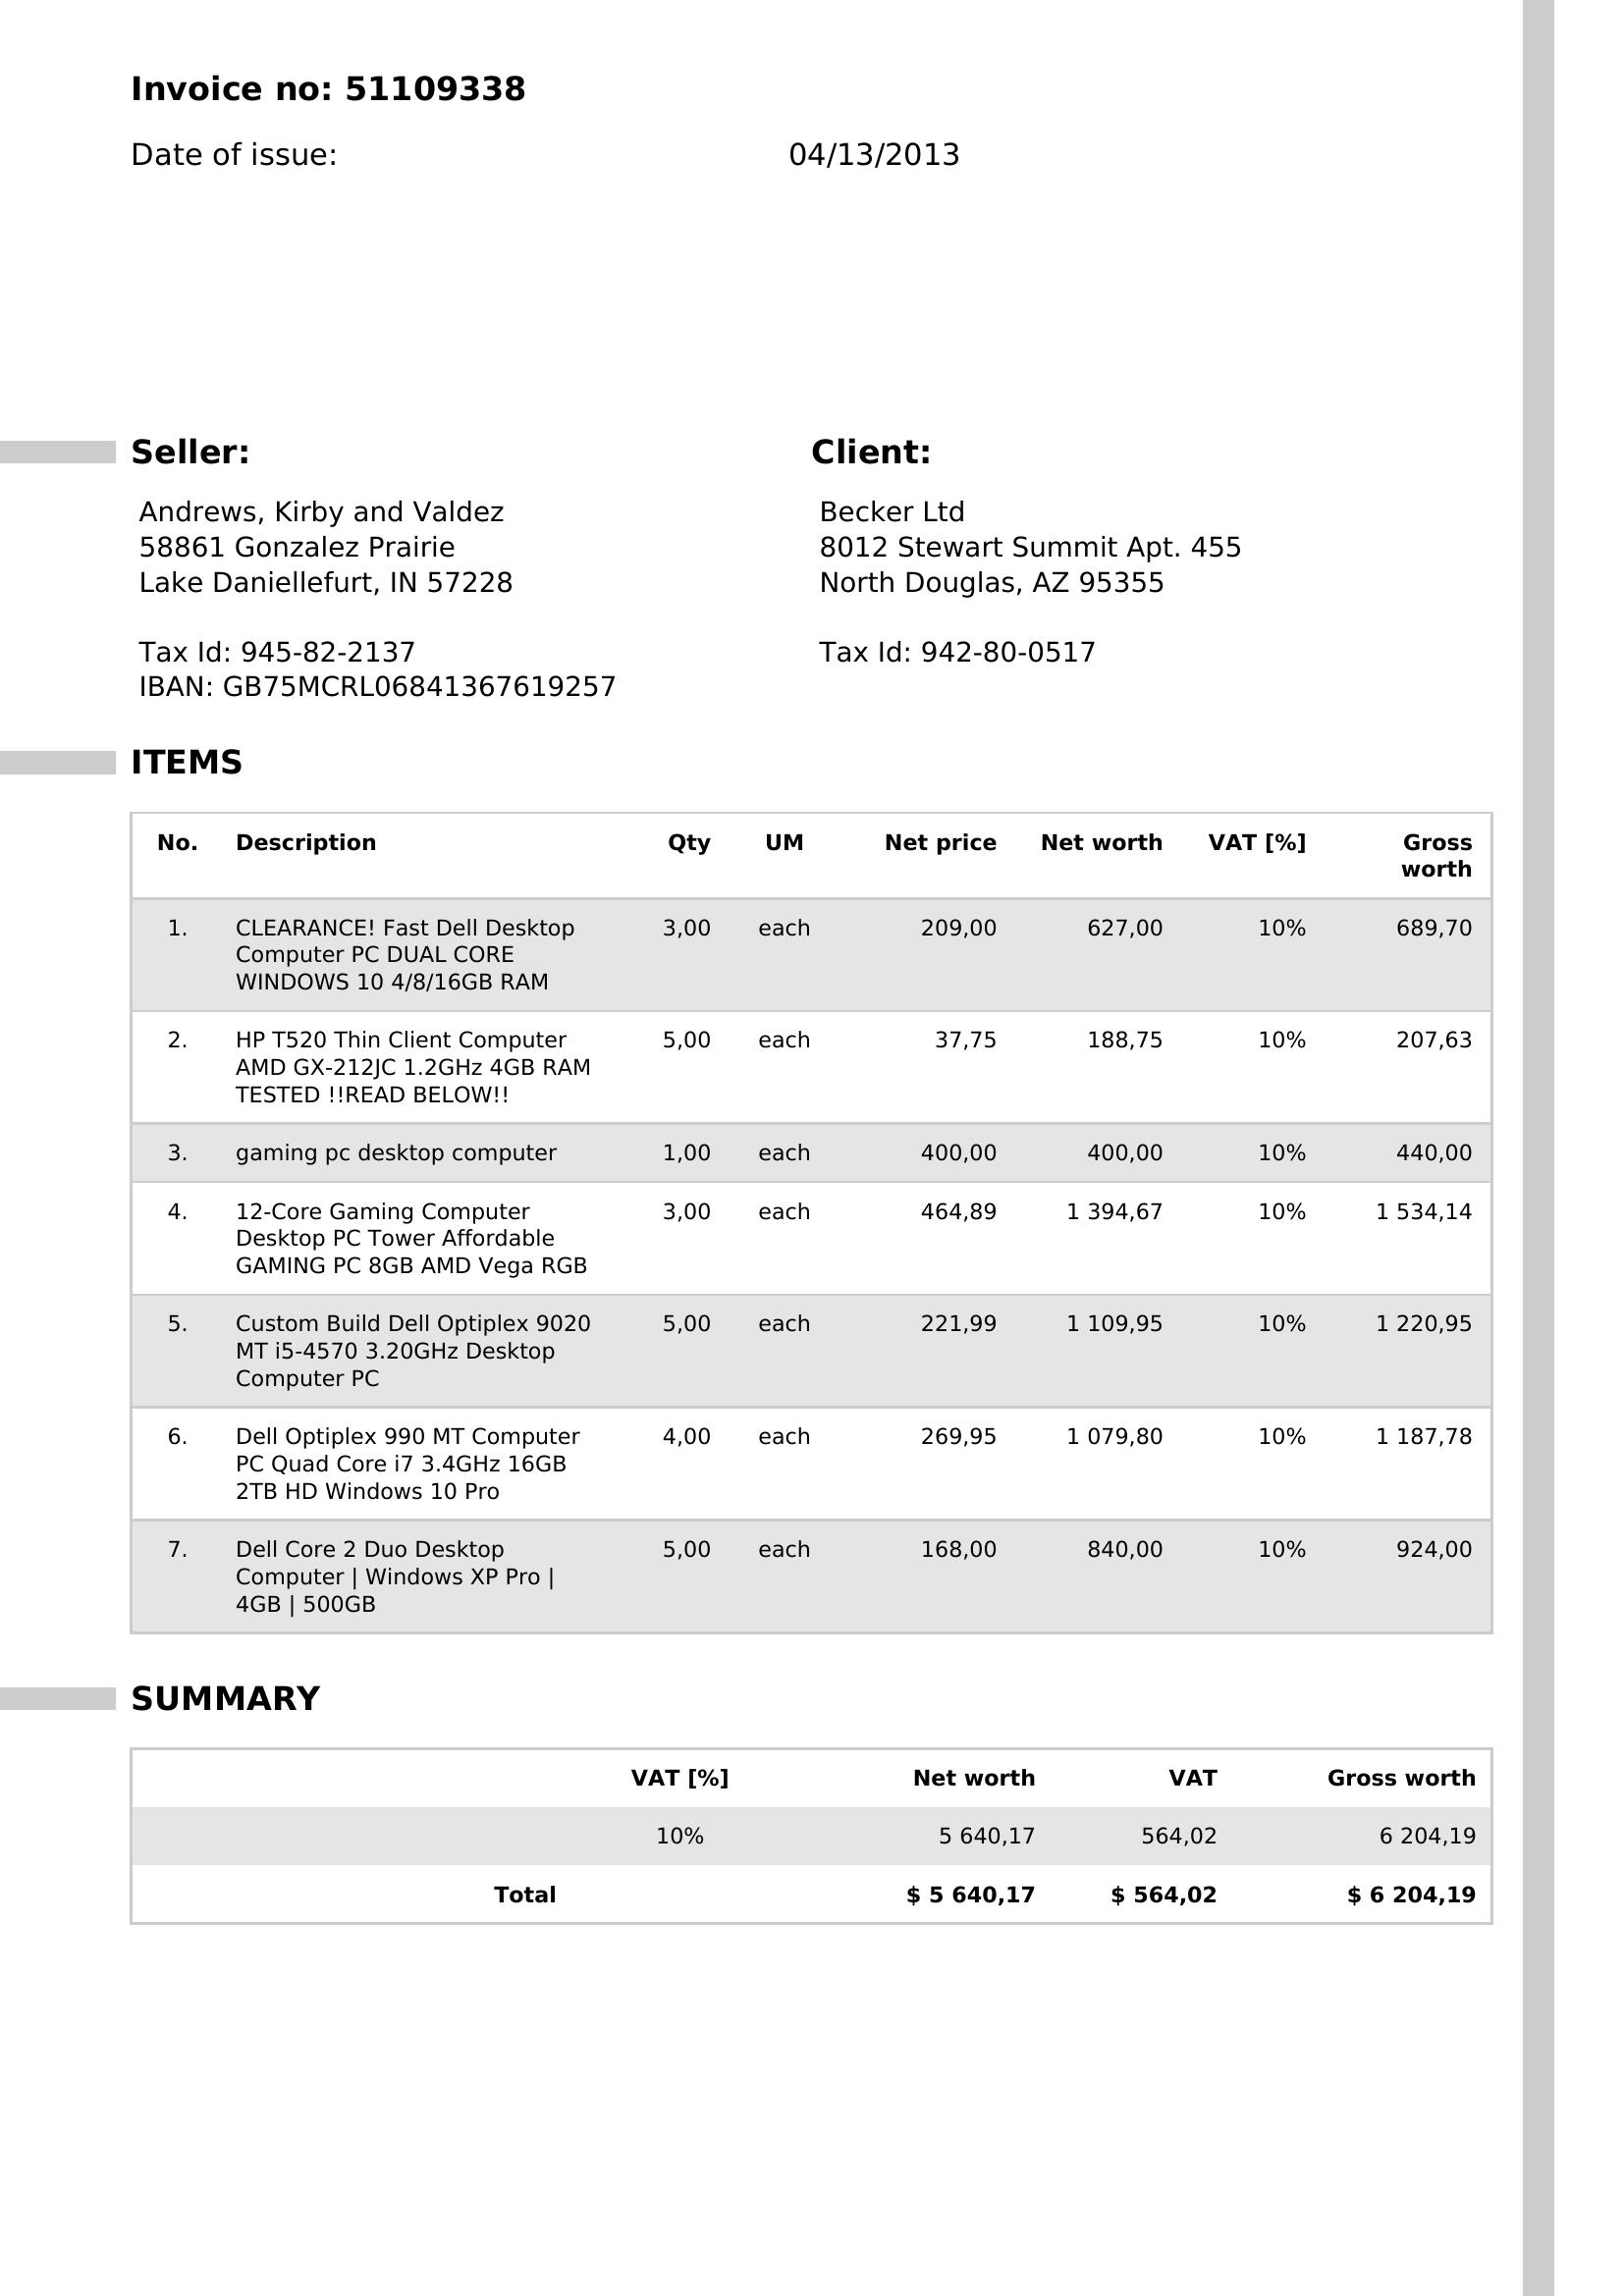

In [2]:
show_receipt_preview()

In [3]:
worksheet_box(
    "receipt_observation",
    answers_path=answer_path('06_receipt_ocr'),
    question_label="QUESTION 19 · Inspect the first invoice",
    response_label="From the image, what are the invoice number, issue date and final total? Note anything unclear:",
)

<style>
/* Keep the lesson inside the available notebook width. */
.workshop-reading { background:#FFFFFF; color:#1D2939; color-scheme:light;
  padding:16px; border:1px solid #D0D5DD; border-radius:12px;
  line-height:1.6; box-sizing:border-box; max-width:100%; overflow-wrap:anywhere; }
.workshop-reading :is(p,li,td,th,h1,h2,h3,h4,summary,strong,b,small,em) { color:inherit; }
.workshop-reading a { color:#1849A9 !important; text-decoration:underline; }
.workshop-reading :is(code,kbd) { color:#1D2939 !important; background:#F2F4F7 !important;
  border-radius:4px; padding:1px 4px; overflow-wrap:anywhere; }
.workshop-reading table { display:block; max-width:100%; overflow-x:auto;
  color:#1D2939; background:#FFFFFF; }
.workshop-reading :is(th,td) { border-color:#D0D5DD; background:transparent; }
.workshop-reading pre { color:#1D2939; background:#F8FAFC; white-space:pre-wrap;
  max-width:100%; overflow-x:auto; box-sizing:border-box; }
.workshop-reading :is(img,svg) { max-width:100%; height:auto; }
.workshop-reading .workshop-flex { display:flex; flex-wrap:wrap; max-width:100%; }
.workshop-reading .workshop-flex > * { min-width:0; max-width:100%; box-sizing:border-box; }
.workshop-widget { background:#FFFFFF !important; color:#1D2939 !important; color-scheme:light; }
.workshop-widget :is(label,.widget-label) { color:#1D2939 !important; }
.workshop-widget textarea { background:#FFFFFF !important; color:#1D2939 !important;
  caret-color:#1D2939; border:1px solid #667085 !important; }
.workshop-widget button { background:#175CD3 !important; color:#FFFFFF !important; }
.workshop-widget button.mod-success { background:#067647 !important; }
.workshop-widget button.mod-danger { background:#B42318 !important; }
.workshop-widget button:focus-visible, .workshop-reading a:focus-visible {
  outline:3px solid #B54708; outline-offset:3px; }
</style>
<div class="workshop-reading" style="background:#FFFFFF;color:#1D2939;color-scheme:light;max-width:100%;box-sizing:border-box;padding:16px;border:1px solid #D0D5DD;border-radius:12px;overflow-wrap:anywhere">

### 2 · Describe Iteration 1 to your coding agent

Open a fresh Copilot Chat. You can use **Agent** mode to create the script, or
**Ask** mode to get code that you paste into the file yourself.
Use the public classroom images only; do not upload private customer invoices to a cloud chatbot.

| Part | Your first version |
|---|---|
| Input | Only `_for_STUDENT/data/notebook6/batch1_1/batch1-0001.jpg` |
| Script | `_for_STUDENT/tasks/06_receipt_ocr/receipt_reader.py` |
| Model | Local GLM-OCR, using the provided `model/glm_reader.py` helper |
| Output | `_for_STUDENT/outputs/06_receipt_ocr/first_receipt.xlsx`, with a header and exactly one data row |
| Evidence | Save the raw model response to `_for_STUDENT/outputs/06_receipt_ocr/first_receipt_ocr.txt` |

Include these Excel columns:

`source_file`, `invoice_number`, `invoice_date`, `seller_name`, `tax_total`,
`grand_total`, `currency_mark`, `review_note`.

- Keep invoice numbers as text so leading zeros are not lost.
- Keep the returned date as text and compare it with the printed date; flag a changed format rather than pretending it was copied exactly.
- Distinguish **tax** from the **grand total**, and handle amounts such as `6 204,19`.
- A printed `$` is a currency mark, not proof of a particular country's currency.
- Leave uncertain fields blank and explain them in `review_note`; never invent a value.
- Check that the response is valid JSON with the fields you need; remove Markdown fences if present. A missing key is not a zero.
- Keep the input image and reference CSV unchanged. Do not process the whole folder yet.

<details>
<summary><b>Hint · Build your prompt in small steps</b></summary>

1. **Name the file:** "Within `_for_STUDENT/tasks/06_receipt_ocr`, generate a Python script for me and name it `receipt_reader.py`."
2. **Name the input and scope:** give the exact first-image path and say "one image only".
3. **Name the local model:** import `read_image` from `model.glm_reader` and call `read_image(image_path, prompt)`. This provided helper handles local GLM-OCR; `openpyxl` can write Excel.
4. **Describe the columns and schema:** ask for a prompt containing a JSON schema. Use the invoice's printed labels: the final **SUMMARY** row contains **Net worth**, **VAT**, and **Gross worth**. Ask for these separately, map VAT to tax and Gross worth to grand total, and check that net + tax equals total. A Tax Id is not a tax amount. Include invoice number, date, seller and printed currency mark. Say how missing values and changed date formats should be recorded.
5. **Name both outputs:** give the Excel and raw-text paths. Ask the script to create the output folder and find paths relative to its own location.
6. **Add your check:** ask for the run command and an explanation of what to inspect. Run it, compare with the image, and request one small fix if needed.

The model proposes fields; the agent-generated Python validates and maps the
response into a spreadsheet. Keep those jobs clear when asking for a change.

</details>

<div style='background:#FFFAEB;border:1px solid #FEDF89;border-left:5px solid #B54708;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#FFFAEB;border:1px solid #FEDF89;color:#B54708;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>KEEP THE CHECK INDEPENDENT</span><div style='margin-top:9px'>The CSV has <b>File Name</b>, <b>Json Data</b> and <b>OCRed Text</b> columns. It is a reference for checking afterwards, not an OCR shortcut. Its rows are not in image-filename order: find <b>batch1-0001.jpg</b> using <b>File Name</b>, not the first CSV row. Do not let the script copy answers from the CSV or hard-code the values you inspected.</div></div>

### 3 · Run your script and view the spreadsheet

From the repository root:

```bash
python _for_STUDENT/tasks/06_receipt_ocr/receipt_reader.py
```

The file is created by you or your coding agent, not by this notebook.

Open **Extensions** (`Ctrl+Shift+X`, or `Command+Shift+X` on macOS), search for
**SpreadJS XLSX Editor** by **MESCIUS**, and install it if needed.
[Extension details](https://marketplace.visualstudio.com/items?itemName=Mescius.spreadjs-xlsx-editor).
Then open `_for_STUDENT/outputs/06_receipt_ocr/first_receipt.xlsx` in the Explorer. If necessary,
right-click the file, choose **Open With…**, and select the spreadsheet editor.
You do not need Microsoft Excel installed on your laptop.

Alternatively, run the next cell to view the spreadsheet inside this notebook.
It is a read-only preview; it does not create example answers or run your script.

</div>

In [4]:
preview_spreadsheet()

In [5]:
worksheet_box(
    "receipt_verification",
    answers_path=answer_path('06_receipt_ocr'),
    question_label="QUESTION 20 · Check your extracted row",
    response_label="Which fields matched the image? Which need checking, and what one change would you ask the agent to make next?",
    reveal_html="<div style='background:#ECFDF3;border:1px solid #ABEFC6;border-left:5px solid #067647;border-radius:12px;padding:15px 17px;margin:12px 0;color:#344054;line-height:1.55;box-sizing:border-box;max-width:100%;overflow-wrap:anywhere'><span style='display:inline-block;background:#ECFDF3;border:1px solid #ABEFC6;color:#067647;border-radius:999px;padding:2px 9px;font-size:0.76rem;font-weight:700;letter-spacing:0.04em;white-space:normal;max-width:100%;box-sizing:border-box;overflow-wrap:anywhere'>CHECK BEFORE SCALING UP</span><div style='margin-top:9px'>A readable spreadsheet is not proof of correct data. Check the filename, date, seller and totals against the image. Keep raw OCR text so a mistake can be traced. GLM-OCR can omit fields or normalise dates; flag these differences rather than guessing. Get one invoice right before processing more.</div></div>",
)

<style>
/* Keep the lesson inside the available notebook width. */
.workshop-reading { background:#FFFFFF; color:#1D2939; color-scheme:light;
  padding:16px; border:1px solid #D0D5DD; border-radius:12px;
  line-height:1.6; box-sizing:border-box; max-width:100%; overflow-wrap:anywhere; }
.workshop-reading :is(p,li,td,th,h1,h2,h3,h4,summary,strong,b,small,em) { color:inherit; }
.workshop-reading a { color:#1849A9 !important; text-decoration:underline; }
.workshop-reading :is(code,kbd) { color:#1D2939 !important; background:#F2F4F7 !important;
  border-radius:4px; padding:1px 4px; overflow-wrap:anywhere; }
.workshop-reading table { display:block; max-width:100%; overflow-x:auto;
  color:#1D2939; background:#FFFFFF; }
.workshop-reading :is(th,td) { border-color:#D0D5DD; background:transparent; }
.workshop-reading pre { color:#1D2939; background:#F8FAFC; white-space:pre-wrap;
  max-width:100%; overflow-x:auto; box-sizing:border-box; }
.workshop-reading :is(img,svg) { max-width:100%; height:auto; }
.workshop-reading .workshop-flex { display:flex; flex-wrap:wrap; max-width:100%; }
.workshop-reading .workshop-flex > * { min-width:0; max-width:100%; box-sizing:border-box; }
.workshop-widget { background:#FFFFFF !important; color:#1D2939 !important; color-scheme:light; }
.workshop-widget :is(label,.widget-label) { color:#1D2939 !important; }
.workshop-widget textarea { background:#FFFFFF !important; color:#1D2939 !important;
  caret-color:#1D2939; border:1px solid #667085 !important; }
.workshop-widget button { background:#175CD3 !important; color:#FFFFFF !important; }
.workshop-widget button.mod-success { background:#067647 !important; }
.workshop-widget button.mod-danger { background:#B42318 !important; }
.workshop-widget button:focus-visible, .workshop-reading a:focus-visible {
  outline:3px solid #B54708; outline-offset:3px; }
</style>
<div class="workshop-reading" style="background:#FFFFFF;color:#1D2939;color-scheme:light;max-width:100%;box-sizing:border-box;padding:16px;border:1px solid #D0D5DD;border-radius:12px;overflow-wrap:anywhere">

### Stop after one checked receipt

- [ ] The Excel file contains a header and exactly one invoice row.
- [ ] The row names the source image and separates tax from the grand total.
- [ ] Missing or uncertain fields are clearly marked for review.
- [ ] You compared the values with the image, not just the appearance of the spreadsheet.
- [ ] The original images and CSV are unchanged.

Later we can add a second receipt and improve the script one step at a time.

</div>